## **DAY 7 — Decision Trees + Random Forest + XGBoost Basics**

### **The Professional Dataset**

To ensure consistency, we will use this **Social Media Ad Click** dataset for every model in this tutorial.

*   **Features:** `Age` (Numeric), `Daily_Time_Spent` (Numeric).
*   **Target:** `Clicked` (0 = No, 1 = Yes).

In [174]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Create the professional dataset
data = {
    'Age': [22, 44, 30, 38, 25, 41, 52, 27, 35, 48],
    'Daily_Time_Spent': [45, 80, 55, 75, 40, 85, 90, 50, 65, 70],
    'Clicked': [0, 1, 0, 1, 0, 1, 1, 0, 0, 1]
}

df = pd.DataFrame(data)

# 2. Define Features (X) and Target (y)
X = df[['Age', 'Daily_Time_Spent']]
y = df['Clicked']

# 3. Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Unified dataset prepared!")
display(df.head())

Unified dataset prepared!


,Age,Daily_Time_Spent,Clicked
0,22,45,0
1,44,80,1
2,30,55,0
3,38,75,1
4,25,40,0


---

## **PART 1 — Tree-Based Models**

Tree models work by **splitting your data into different groups based on simple questions**.

### **Conceptual Example**
Imagine a model deciding if a candidate gets a high salary:
* **Question:** Does the person have more than 5 years of experience?
    * **Yes:** Likely a High Salary
    * **No:** Likely a Low Salary

---

### **Why Tree Models Are So Useful**

* **Handles Complex Patterns:** They don't just look for straight lines; they can find complex, 'step-like' relationships in your data.
* **Industry Standard for Tabular Data:** These models are usually the best choice for data stored in spreadsheets or databases (like SQL tables).
* **No Scaling Required:** Unlike Neural Networks, you don't have to scale your numbers (0 to 1 range) before using them.
* **Feature Interactions:** They automatically figure out how different pieces of information (like Age and Education) combined affect the result.
* **Interpretability:** They are not 'black boxes'; they can tell you exactly which factors were most important in making a decision.

---

## **PART 2 — Decision Tree**

A Decision Tree splits data step-by-step using conditions.

### **Key Parameters Used:**
*   **`random_state=42`**: This is the 'seed' for the model. It ensures that every time you run the code, the splits happen exactly the same way, making your results reproducible.

### **Classification vs Regression**
*   **Classification:** Used for categories (Fraud vs. Not Fraud).
*   **Regression:** Used for numbers (Predicting house prices).

In [175]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Model
# We use random_state=42 to ensure results are the same every time we run it
model = DecisionTreeClassifier(random_state=42)

# 2. Train the Model on our professional dataset
model.fit(X_train, y_train)

# 3. Make Predictions
predictions = model.predict(X_test)

print("Decision Tree predictions complete.")
print(f"Predictions: {predictions}")
print(f"Actual Values: {y_test.values}")

Decision Tree predictions complete.
Predictions: [1 1]
Actual Values: [0 1]


---

## **PART 3 — Gini Impurity**

Decision Trees need a way to decide which question to ask first. They use **Gini Impurity** to measure how 'mixed up' the resulting groups are.

*   **Gini = 0:** The group is perfectly pure (e.g., everyone in the group 'Bought').
*   **Gini = 0.5:** The group is a perfect 50/50 mix (maximum impurity/disorder).

### **The Formula**
$$\text{Gini} = 1 - \sum (p_i)^2$$
Where $p_i$ is the probability of each class (e.g., the chance of clicking vs. not clicking).

### **Why it Matters**
At every step, the model calculates the Gini Impurity for every possible split. It chooses the split that results in the **lowest** impurity, effectively 'cleaning' the data step-by-step.

In [176]:
# Let's calculate the starting Gini Impurity for our dataset
p_click = df['Clicked'].mean()
p_no_click = 1 - p_click

gini_impurity = 1 - (p_click**2 + p_no_click**2)

print(f"Probability of Click: {p_click}")
print(f"Probability of No Click: {p_no_click}")
print(f"Starting Gini Impurity for this dataset: {gini_impurity:.3f}")

Probability of Click: 0.5
Probability of No Click: 0.5
Starting Gini Impurity for this dataset: 0.500


---

## **PART 4 — Professional Evaluation Metrics**

In a professional setting, we don't just look at raw numbers. We use standardized metrics to evaluate performance, often expressed as percentages.

In [177]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Calculate Metrics
# we use zero_division=0 to handle cases with small datasets where a class might not be predicted
acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, zero_division=0)
rec = recall_score(y_test, predictions, zero_division=0)

# 2. Display formatted as clean integers/percentages
print(f"Model Performance Summary:")
print(f"---")
print(f"Accuracy:  {int(acc * 100)}%")
print(f"Precision: {int(prec * 100)}%")
print(f"Recall:    {int(rec * 100)}%")

Model Performance Summary:
---
Accuracy:  50%
Precision: 50%
Recall:    100%


---

## **PART 5 — Random Forest: The Power of the Committee**

A **Random Forest** trains many individual Decision Trees on different subsets of the data and averages their results.

### **Key Parameters Used:**
*   **`n_estimators=100`**: This defines the number of trees in the forest. Generally, more trees increase accuracy but make the model slower to train.
*   **`random_state=42`**: Ensures the random selection of data for each tree is consistent across runs.

In [178]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest
# n_estimators=100 means we are using 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train on our professional dataset
rf_model.fit(X_train, y_train)

# 3. Make Predictions
rf_predictions = rf_model.predict(X_test)

# 4. Evaluate using the same professional metrics
rf_acc = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Performance:")
print(f"---")
print(f"Accuracy: {int(rf_acc * 100)}%")

Random Forest Performance:
---
Accuracy: 50%


---

## **PART 6 — XGBoost: The Gradient Booster**

**XGBoost** builds trees sequentially, where each new tree specifically tries to correct the errors of the previous ones.

### **Key Parameters Used:**
*   **`eval_metric='logloss'`**: This stands for 'Logarithmic Loss'. It is the scoring function the model uses during training to calculate how far its predictions are from the actual values.
*   **`random_state=42`**: Standardizes the boosting process for consistent results.

In [179]:
from xgboost import XGBClassifier

# 1. Initialize XGBoost
# Removed 'use_label_encoder' to fix the UserWarning
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# 2. Train the model
xgb_model.fit(X_train, y_train)

# 3. Make Predictions
xgb_predictions = xgb_model.predict(X_test)

# 4. Evaluate
xgb_acc = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Performance:")
print(f"---")
print(f"Accuracy: {int(xgb_acc * 100)}%")

XGBoost Performance:
---
Accuracy: 100%


---

## **PART 7 — Final Visual Analysis: The Confusion Matrix**

While accuracy tells us the overall score, a **Confusion Matrix** shows us the specific details of where the model succeeded and where it failed.

*   **True Positives:** Predicted 'Click' and they actually clicked.
*   **True Negatives:** Predicted 'No Click' and they actually didn't click.
*   **False Positives/Negatives:** The mistakes made by the model.

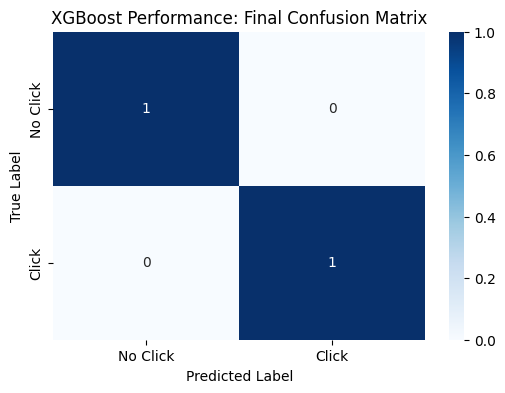

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Create a Confusion Matrix for our best model (XGBoost)
cm = confusion_matrix(y_test, xgb_predictions)

# 2. Visualize it using Seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Click', 'Click'],
            yticklabels=['No Click', 'Click'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Performance: Final Confusion Matrix')
plt.show()

---
## **PART 8 — Professional Comparison Pipeline**

In a real-world project, you wouldn't write separate code for every model. Instead, you would use a **Pipeline** to loop through multiple models and compare their results in one go.

In [181]:
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Define the list of models we want to compare
comparison_models = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(eval_metric='logloss', random_state=42))
]

results = []

# 2. Loop through each model and evaluate
for name, model_obj in comparison_models:
    # Train
    model_obj.fit(X_train, y_train)
    # Predict
    preds = model_obj.predict(X_test)
    # Score
    score = accuracy_score(y_test, preds)

    results.append({
        'Model': name,
        'Accuracy': f"{int(score * 100)}%"
    })

# 3. Display the final comparison table
comparison_df = pd.DataFrame(results)
print("Final Model Comparison Results:")
display(comparison_df)

Final Model Comparison Results:


,Model,Accuracy
0,Decision Tree,50%
1,Random Forest,50%
2,XGBoost,100%


_________________________________________
<br>

## **PART 9 — Practice Question**

Use the dataset below to try and predict if a customer will make a purchase. Notice that we've added a **City_Type** category—remember to encode this before training your models!

In [182]:
import pandas as pd

# Improved Practice Dataset
data = {
    'Age': [22, 25, 30, 35, 40, 28, 32, 45, 50, 29, 31, 24, 55, 33, 42],
    'Income': [25000, 30000, 40000, 50000, 70000, 35000, 45000, 80000, 90000, 38000, 42000, 28000, 100000, 52000, 75000],
    'City_Type': ['Rural', 'Rural', 'Urban', 'Urban', 'Urban', 'Rural', 'Urban', 'Urban', 'Rural', 'Rural', 'Urban', 'Rural', 'Urban', 'Urban', 'Rural'],
    'Purchased': [0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1]
}

practice_df = pd.DataFrame(data)

print("Practice dataset with categorical variables ready!")
display(practice_df.head())

Practice dataset with categorical variables ready!


,Age,Income,City_Type,Purchased
0,22,25000,Rural,0
1,25,30000,Rural,0
2,30,40000,Urban,0
3,35,50000,Urban,1
4,40,70000,Urban,1


In [183]:
#STEP 1: IMPOET ALL LIBRARIES
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [184]:
#STEP 2: ENCODE THE City_type TO (0 and 1) use .map({})
practice_df['City_Type'] = practice_df['City_Type'].map({'Rural': 0, 'Urban': 1})

print("Mapping successful!")
display(practice_df.head())

Mapping successful!


,Age,Income,City_Type,Purchased
0,22,25000,0,0
1,25,30000,0,0
2,30,40000,1,0
3,35,50000,1,1
4,40,70000,1,1


In [187]:
#STEP 3: USE TTS

X = practice_df[['Age', 'Income', 'City_Type']]
y = practice_df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print("TTS successful!")

TTS successful!


In [196]:
#STEP 4: DECISION TREE MODEL

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

#STEP 5: ACCURACCY SCORE AND MATRIX
dt_score = accuracy_score(y_test, dt_predictions)
cm = confusion_matrix(y_test, dt_predictions)

print(f"Decision Tree Performance:")
print(f"---")
print(f"Accuracy: {int(acc_score * 100)}%")
print(f"Confusion Matrix:")
print(cm)

Decision Tree Performance:
---
Accuracy: 66%
Confusion Matrix:
[[0 1]
 [0 2]]


In [194]:
#STEP 5: RANDOMFOREST MODEL
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

#STEP 6: ACCURACCY SCORE AND MATRIX
rf_score = accuracy_score(y_test, rf_predictions)
cm = confusion_matrix(y_test, rf_predictions)

print(f"Random Forest Performance:")
print(f"---")
print(f"Accuracy: {int(acc_score * 100)}%")
print(f"Confusion Matrix:")
print(cm)

Random Forest Performance:
---
Accuracy: 66%
Confusion Matrix:
[[0 1]
 [0 2]]


In [195]:
#STEP 6: XGBOOST MODEL
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

#STEP 7: ACCURACCY SCORE
xgb_score = accuracy_score(y_test, xgb_predictions)
cm = confusion_matrix(y_test, xgb_predictions)

print(f"XGBoost Performance:")
print(f"---")
print(f"Accuracy: {int(acc_score * 100)}%")
print(f"Confusion Matrix:")
print(cm)

XGBoost Performance:
---
Accuracy: 66%
Confusion Matrix:
[[0 1]
 [0 2]]


In [202]:
#STEP 8: PIPELINE COMPARISION
from sklearn.pipeline import Pipeline

comparison_models = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(eval_metric='logloss', random_state=42))

]

for name , model_obj in comparison_models:
    model_obj.fit(X_train, y_train)
    preds = model_obj.predict(X_test)
    score = accuracy_score(y_test, preds)

    print('---------------------------------------')
    print(f"{name} Accuracy: {int(score * 100)}%")
    print(f"{name} Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print('---------------------------------------')




---------------------------------------
Decision Tree Accuracy: 66%
Decision Tree Confusion Matrix:
[[0 1]
 [0 2]]
---------------------------------------
---------------------------------------
Random Forest Accuracy: 66%
Random Forest Confusion Matrix:
[[0 1]
 [0 2]]
---------------------------------------
---------------------------------------
XGBoost Accuracy: 66%
XGBoost Confusion Matrix:
[[0 1]
 [0 2]]
---------------------------------------
